## Setup Environment

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import yaml

from breast_cancer.data import prepare_dataset

2025-09-22 10:16:53.296380: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-22 10:16:53.452487: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-22 10:16:54.056947: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2025-09-22 10:16:54.057033: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or 

In [2]:
# Check installed tensorflow version
print(f"Tensorflow version: {tf.__version__}")

# Check GPU availability
print(f"GPU List: {tf.config.list_physical_devices('GPU')}")

Tensorflow version: 2.10.1
GPU List: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load Test data

In [3]:
# Import general configurations
with open("../configs/default.yml") as f:
    default_cfg = yaml.load(f, Loader=yaml.FullLoader)

In [4]:
# Setup testing data for evaluation
df_test_patient_random = pd.read_csv("/workspace/breast_cancer/data/splits/test_patient_random.csv")

ds_test_patient_random = prepare_dataset( # use prepare dataset, only converting path to image and get labels
    df_test_patient_random["processed"].values,
    df_test_patient_random["label"].values,
    image_resize=(default_cfg["image_resize"], default_cfg["image_resize"])
)

ds_test_patient_random = ds_test_patient_random.batch(64)

2025-09-22 10:16:58.527552: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-22 10:16:58.667685: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22282 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


In [5]:
imgs, lbls = next(iter(ds_test_patient_random))

label:  0


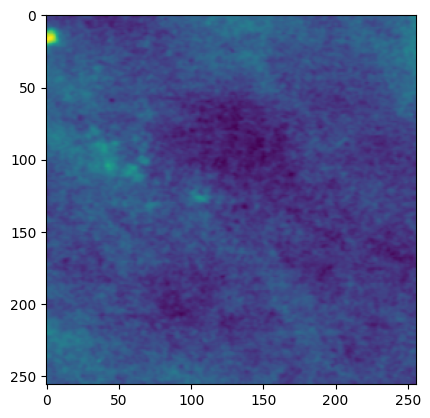

In [6]:
plt.imshow(imgs[0])

print("label: ", lbls[0].numpy())

## Load Final Model

In [7]:
final_model_path = "/workspace/breast_cancer/models/final/cnn_extended/cnn_extended_patient_random.h5"

model = tf.keras.models.load_model(final_model_path)

In [8]:
model.input_shape, model.output_shape

((None, 256, 256, 1), (None, 1))

In [9]:
model.summary()

Model: "cnn_extended"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 256, 256, 1)]     0         
                                                                 
 conv2d_8 (Conv2D)           (None, 252, 252, 4)       104       
                                                                 
 conv2d_9 (Conv2D)           (None, 250, 250, 8)       296       
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 125, 125, 8)      0         
 2D)                                                             
                                                                 
 batch_normalization_8 (Batc  (None, 125, 125, 8)      32        
 hNormalization)                                                 
                                                                 
 spatial_dropout2d_6 (Spatia  (None, 125, 125, 8)     

In [10]:
# Final evaluation
model.evaluate(ds_test_patient_random)

2025-09-22 10:17:33.809242: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8905
2025-09-22 10:17:33.860357: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-22 10:17:33.862579: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-22 10:17:33.862604: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2025-09-22 10:17:33.863853: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-22 10:17:33.863942: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.


 4/13 [========>.....................] - ETA: 0s - loss: 0.7077 - auc_2: 0.0000e+00 - binary_accuracy: 0.4922 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00 

2025-09-22 10:17:34.139645: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


13/13 [==============================] - 1s 22ms/step - loss: 0.7246 - auc_2: 0.6866 - binary_accuracy: 0.6043 - precision_2: 0.5253 - recall_2: 0.8012   


[0.724564790725708,
 0.6866495609283447,
 0.6043257117271423,
 0.5252918004989624,
 0.8011869192123413]

## Compare with model that has not been trained

In [11]:
initial_weights_path = "/workspace/breast_cancer/models/initial/cnn_extended/cnn_extended"

# Load initial model weights before training
model.load_weights(initial_weights_path)

In [12]:
model.evaluate(ds_test_patient_random)

13/13 [==============================] - 0s 14ms/step - loss: 10.4942 - auc_2: 0.5000 - binary_accuracy: 0.4288 - precision_2: 0.4288 - recall_2: 1.0000          


[10.494227409362793, 0.5, 0.42875316739082336, 0.42875316739082336, 1.0]